# Simple neural network for diabetes classification

A small baseline neural network for the diabetes-risk assignment.

- **Target:** `Diabetes_binary`
- **Inputs:** 21 health-indicator features
- **Architecture:** 21 → 32 → 16 → 1
- **Loss:** `BCEWithLogitsLoss`
- **Evaluation:** validation set during training, untouched test set at the end

The model is intentionally kept simple so it can be expanded later for XAI analysis.


In [2]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
# Loads the dataset
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nTarget distribution:")
print(df["Diabetes_binary"].value_counts())


Dataset shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0



Target distribution:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [4]:
# Separate features and target
target_col = "Diabetes_binary"

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

# Keeps 20% completely separate for final testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y #maintains approximately the same proportion of classes in both datasets.
)

# Make a validation set from the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

# Standardize using training data only 
# (If we calculated the mean and standard deviation using all the data, information from the test set would leak into the training process.)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("Number of features:", X_train.shape[1])
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Number of features: 21
Train: (45242, 21)
Validation: (11311, 21)
Test: (14139, 21)


In [5]:
# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

batch_size = 256

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)


In [6]:
# This is our neural network (small and simple)

class DiabetesNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


model = DiabetesNN(n_features=X_train.shape[1])

# BCEWithLogitsLoss already includes the sigmoid operation internally
# BCE = Binary Cross Entropy
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [7]:
# Train the model with simple early stopping

max_epochs = 100 #1 epoch = The neural network has seen every training observation once.
patience = 5 #If validation loss doesn't improve for 5 consecutive epochs, stop training.

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(max_epochs):

    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = (torch.sigmoid(logits) >= 0.5).float()
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

            predictions = (torch.sigmoid(logits) >= 0.5).float()
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = running_val_loss / total
    val_accuracy = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"train acc: {train_accuracy:.3f} | "
        f"val acc: {val_accuracy:.3f}"
    )

    # ----- Early stopping -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

# Use the weights from the epoch with the lowest validation loss
model.load_state_dict(best_model_state)


Epoch 01 | train loss: 0.5673 | val loss: 0.5091 | train acc: 0.714 | val acc: 0.751
Epoch 02 | train loss: 0.5088 | val loss: 0.5051 | train acc: 0.750 | val acc: 0.753
Epoch 03 | train loss: 0.5060 | val loss: 0.5044 | train acc: 0.751 | val acc: 0.751
Epoch 04 | train loss: 0.5044 | val loss: 0.5036 | train acc: 0.753 | val acc: 0.751
Epoch 05 | train loss: 0.5031 | val loss: 0.5023 | train acc: 0.753 | val acc: 0.752
Epoch 06 | train loss: 0.5018 | val loss: 0.5021 | train acc: 0.754 | val acc: 0.752
Epoch 07 | train loss: 0.5010 | val loss: 0.5018 | train acc: 0.756 | val acc: 0.751
Epoch 08 | train loss: 0.5002 | val loss: 0.5021 | train acc: 0.756 | val acc: 0.752
Epoch 09 | train loss: 0.5000 | val loss: 0.5021 | train acc: 0.757 | val acc: 0.753
Epoch 10 | train loss: 0.4993 | val loss: 0.5015 | train acc: 0.756 | val acc: 0.754
Epoch 11 | train loss: 0.4990 | val loss: 0.5015 | train acc: 0.756 | val acc: 0.753
Epoch 12 | train loss: 0.4986 | val loss: 0.5013 | train acc: 0.7

<All keys matched successfully>

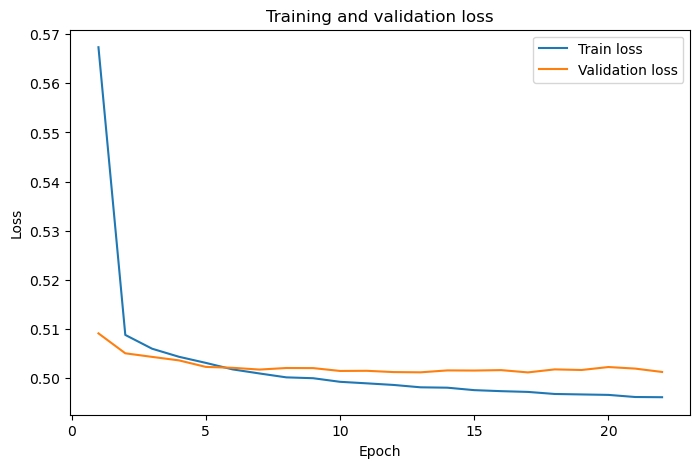

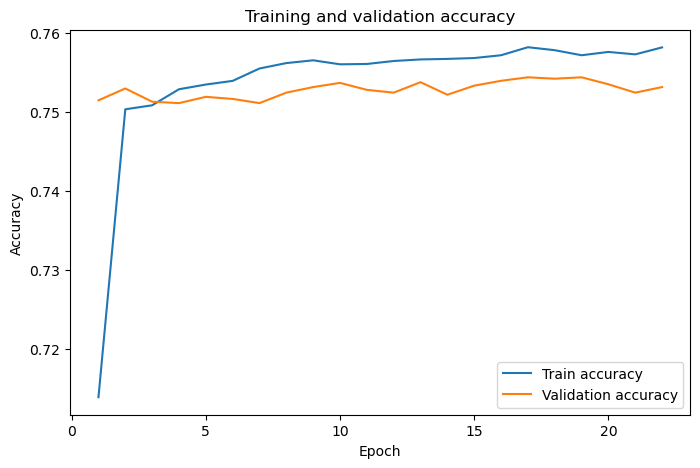

In [8]:
# Plot learning curves
epochs_run = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_run, train_losses, label="Train loss")
plt.plot(epochs_run, val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_run, train_accuracies, label="Train accuracy")
plt.plot(epochs_run, val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()


Test accuracy: 0.752
ROC-AUC:       0.829

Classification report:
              precision    recall  f1-score   support

         0.0      0.780     0.702     0.739      7070
         1.0      0.729     0.802     0.764      7069

    accuracy                          0.752     14139
   macro avg      0.754     0.752     0.751     14139
weighted avg      0.754     0.752     0.751     14139



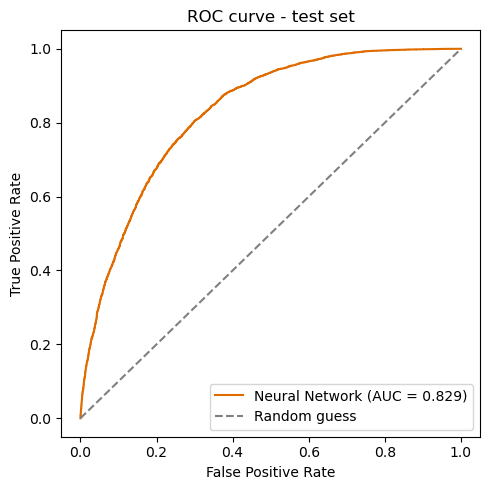

In [9]:
# Evaluation once on the untouched test set
model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)
    test_probabilities = torch.sigmoid(test_logits).cpu().numpy().ravel()

test_predictions = (test_probabilities >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test, test_predictions)
test_auc = roc_auc_score(y_test, test_probabilities)

print(f"Test accuracy: {test_accuracy:.3f}")
print(f"ROC-AUC:       {test_auc:.3f}")

print("\nClassification report:")
print(classification_report(y_test, test_predictions, digits=3))

from sklearn.metrics import roc_curve

fpr_nn, tpr_nn, _ = roc_curve(y_test, test_probabilities)

plt.figure(figsize=(5, 5))
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {test_auc:.3f})', color='#e06c00')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve - test set')
plt.legend()
plt.tight_layout()
plt.show()


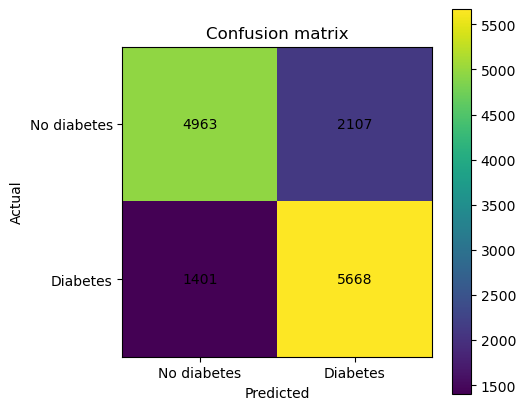

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(5, 5))
image = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No diabetes", "Diabetes"])
ax.set_yticklabels(["No diabetes", "Diabetes"])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(image, ax=ax)
plt.show()
